In [2]:
import os
import json
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
from datetime import datetime

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")

# Paths
DATA_PATH   = "/Users/ashishjain/Documents/assignment/transcript-intelligence/data/processed/all_calls.csv"
CHARTS_PATH = "/Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/"
EXPORTS_PATH= "/Users/ashishjain/Documents/assignment/transcript-intelligence/data/exports/"

print("✅ Imports done")

✅ Imports done


In [4]:
df = pd.read_csv(DATA_PATH)

# Fix list columns
df["topics"]       = df["topics"].apply(ast.literal_eval)
df["action_items"] = df["action_items"].apply(ast.literal_eval)
df["speakers"]     = df["speakers"].apply(ast.literal_eval)
df["key_moments"]  = df["key_moments"].apply(ast.literal_eval)

# Parse dates
df["start_time"]   = pd.to_datetime(df["start_time"])
df["week"]         = df["start_time"].dt.to_period("W")
df["month"]        = df["start_time"].dt.to_period("M")
df["date"]         = df["start_time"].dt.date

print(f"✅ Loaded        : {len(df)} calls")
print(f"📅 Date range   : {df['start_time'].min().date()} → {df['start_time'].max().date()}")
print(f"🏷️  Themes        : {df['theme'].nunique()}")
print(f"📞 Call types   : {df['call_type'].value_counts().to_dict()}")

✅ Loaded        : 100 calls
📅 Date range   : 2026-02-03 → 2026-04-28
🏷️  Themes        : 10
📞 Call types   : {'External': 39, 'Internal': 31, 'Customer Support': 30}


/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/907051454.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"]         = df["start_time"].dt.to_period("W")
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/907051454.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"]        = df["start_time"].dt.to_period("M")


SECTION 1 — SENTIMENT OVERVIEW


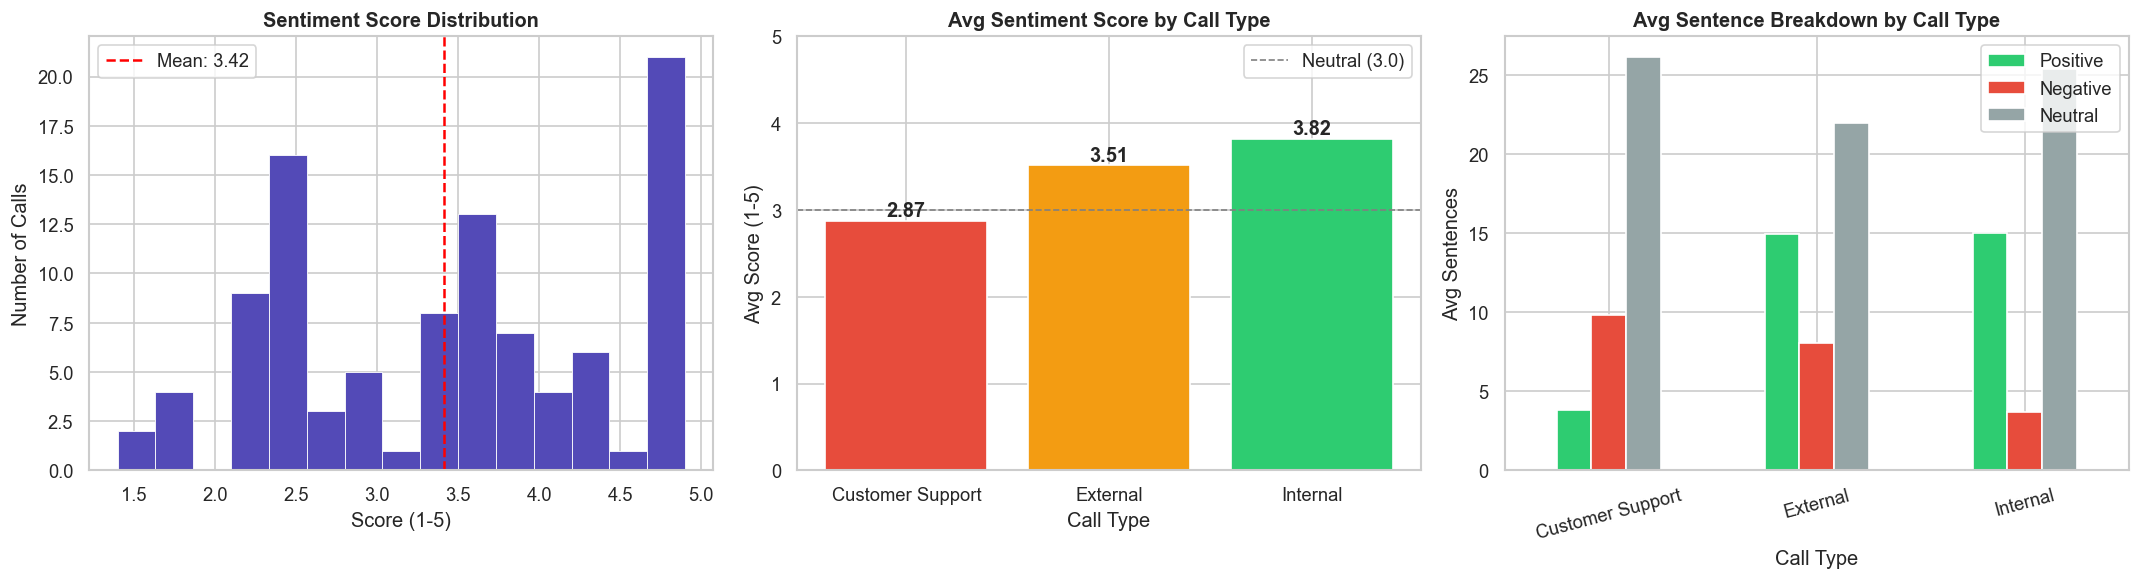


📊 Sentiment Score Stats:
   Overall avg  : 3.42 / 5.0
   Highest avg  : Internal (3.82)
   Lowest avg   : Customer Support (2.87)

✅ Chart saved → sentiment_overview.png


In [5]:
print("=" * 55)
print("SECTION 1 — SENTIMENT OVERVIEW")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Sentiment score distribution
axes[0].hist(df["sentiment_score"], bins=15,
             color="#534AB7", edgecolor="white", linewidth=0.5)
axes[0].axvline(df["sentiment_score"].mean(), color="red",
                linestyle="--", linewidth=1.5,
                label=f"Mean: {df['sentiment_score'].mean():.2f}")
axes[0].set_title("Sentiment Score Distribution", fontweight="bold")
axes[0].set_xlabel("Score (1-5)")
axes[0].set_ylabel("Number of Calls")
axes[0].legend()

# Chart 2 — Avg sentiment score by call type
colors = {"Customer Support": "#e74c3c",
          "External": "#f39c12",
          "Internal": "#2ecc71"}
call_type_sentiment = df.groupby("call_type")["sentiment_score"].mean().sort_values()

bars = axes[1].bar(call_type_sentiment.index,
                   call_type_sentiment.values,
                   color=[colors[c] for c in call_type_sentiment.index])
axes[1].set_title("Avg Sentiment Score by Call Type", fontweight="bold")
axes[1].set_xlabel("Call Type")
axes[1].set_ylabel("Avg Score (1-5)")
axes[1].set_ylim(0, 5)
axes[1].axhline(3.0, color="gray", linestyle="--",
                linewidth=1, label="Neutral (3.0)")
axes[1].legend()
for bar, val in zip(bars, call_type_sentiment.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{val:.2f}", ha="center", fontweight="bold")

# Chart 3 — Sentence sentiment breakdown by call type
sent_data = df.groupby("call_type")[
    ["positive_sents", "negative_sents", "neutral_sents"]
].mean()
sent_data.plot(kind="bar", ax=axes[2],
               color=["#2ecc71", "#e74c3c", "#95a5a6"])
axes[2].set_title("Avg Sentence Breakdown by Call Type", fontweight="bold")
axes[2].set_xlabel("Call Type")
axes[2].set_ylabel("Avg Sentences")
axes[2].legend(["Positive", "Negative", "Neutral"], loc="upper right")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}sentiment_overview.png", bbox_inches="tight")
plt.show()

# Print stats
print(f"\n📊 Sentiment Score Stats:")
print(f"   Overall avg  : {df['sentiment_score'].mean():.2f} / 5.0")
print(f"   Highest avg  : Internal ({df[df['call_type']=='Internal']['sentiment_score'].mean():.2f})")
print(f"   Lowest avg   : Customer Support ({df[df['call_type']=='Customer Support']['sentiment_score'].mean():.2f})")
print(f"\n✅ Chart saved → sentiment_overview.png")

SECTION 2 — SENTIMENT BY THEME


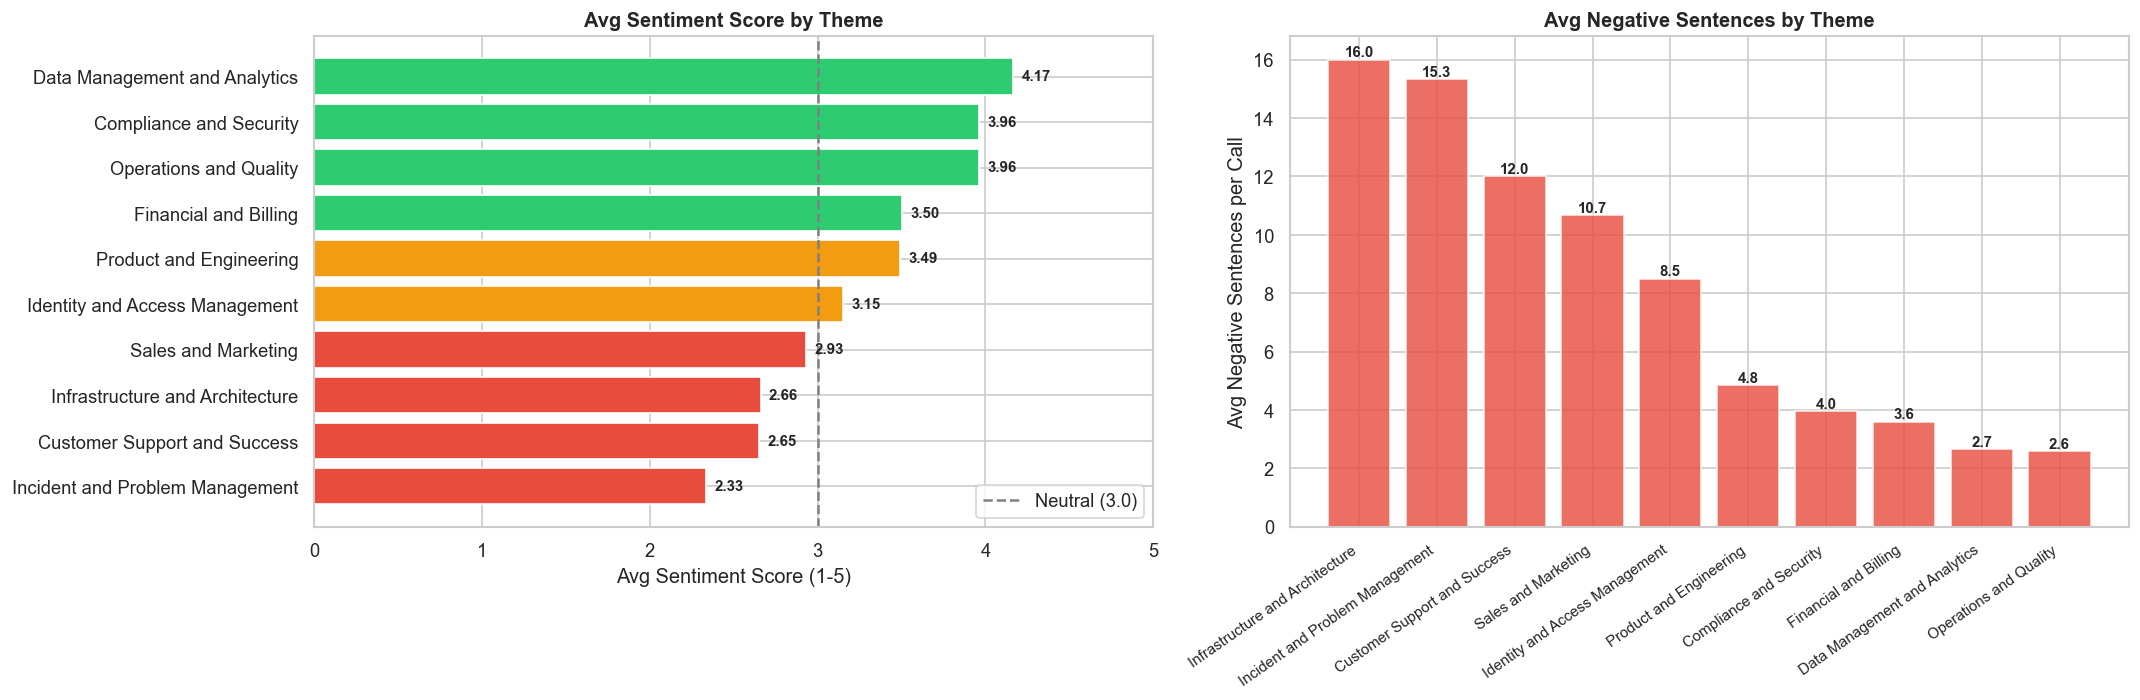


🔴 Most negative themes:
   Incident and Problem Management          → 2.33/5.0
   Customer Support and Success             → 2.65/5.0
   Infrastructure and Architecture          → 2.66/5.0

🟢 Most positive themes:
   Operations and Quality                   → 3.96/5.0
   Compliance and Security                  → 3.96/5.0
   Data Management and Analytics            → 4.17/5.0

✅ Chart saved → sentiment_by_theme.png


In [6]:
print("=" * 55)
print("SECTION 2 — SENTIMENT BY THEME")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1 — Avg sentiment score by theme
theme_sentiment = df.groupby("theme")["sentiment_score"] \
                    .mean().sort_values()
colors = ["#e74c3c" if v < 3.0 else
          "#f39c12" if v < 3.5 else
          "#2ecc71" for v in theme_sentiment.values]

bars = axes[0].barh(theme_sentiment.index,
                    theme_sentiment.values, color=colors)
axes[0].axvline(3.0, color="gray", linestyle="--",
                linewidth=1.5, label="Neutral (3.0)")
axes[0].set_title("Avg Sentiment Score by Theme", fontweight="bold")
axes[0].set_xlabel("Avg Sentiment Score (1-5)")
axes[0].set_xlim(0, 5)
axes[0].legend()
for bar, val in zip(bars, theme_sentiment.values):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va="center", fontweight="bold", fontsize=9)

# Chart 2 — Negative sentences by theme
theme_neg = df.groupby("theme")["negative_sents"] \
              .mean().sort_values(ascending=False)
axes[1].bar(range(len(theme_neg)), theme_neg.values,
            color="#e74c3c", alpha=0.8)
axes[1].set_xticks(range(len(theme_neg)))
axes[1].set_xticklabels(theme_neg.index, rotation=35,
                         ha="right", fontsize=9)
axes[1].set_title("Avg Negative Sentences by Theme", fontweight="bold")
axes[1].set_ylabel("Avg Negative Sentences per Call")
for i, val in enumerate(theme_neg.values):
    axes[1].text(i, val + 0.1, f"{val:.1f}",
                 ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}sentiment_by_theme.png", bbox_inches="tight")
plt.show()

print(f"\n🔴 Most negative themes:")
for theme, score in theme_sentiment.head(3).items():
    print(f"   {theme:<40} → {score:.2f}/5.0")

print(f"\n🟢 Most positive themes:")
for theme, score in theme_sentiment.tail(3).items():
    print(f"   {theme:<40} → {score:.2f}/5.0")
print(f"\n✅ Chart saved → sentiment_by_theme.png")

SECTION 3 — SENTIMENT TRENDS OVER TIME


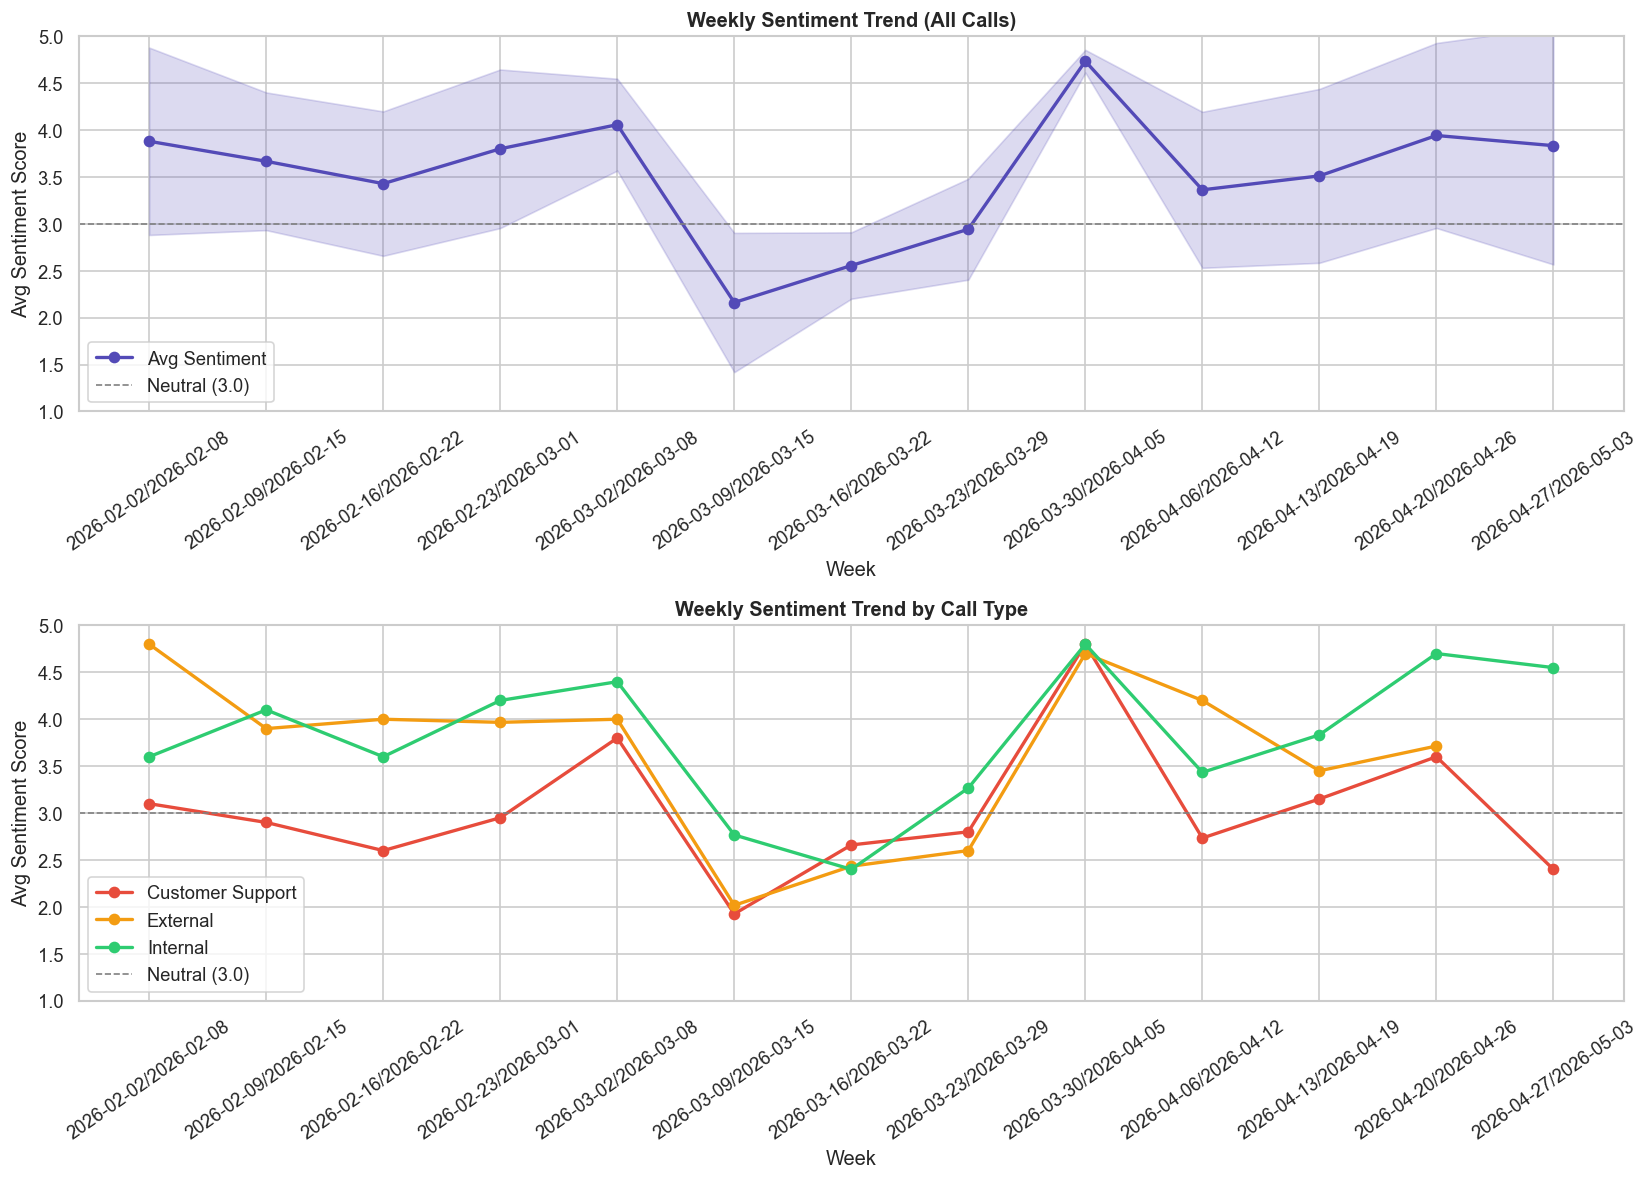

✅ Chart saved → sentiment_trend.png


In [7]:
print("=" * 55)
print("SECTION 3 — SENTIMENT TRENDS OVER TIME")
print("=" * 55)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Weekly sentiment trend overall
weekly = df.groupby("week")["sentiment_score"].agg(["mean", "std"]).reset_index()
weekly["week_str"] = weekly["week"].astype(str)

axes[0].plot(weekly["week_str"], weekly["mean"],
             marker="o", linewidth=2,
             color="#534AB7", label="Avg Sentiment")
axes[0].fill_between(weekly["week_str"],
                     weekly["mean"] - weekly["std"],
                     weekly["mean"] + weekly["std"],
                     alpha=0.2, color="#534AB7")
axes[0].axhline(3.0, color="gray", linestyle="--",
                linewidth=1, label="Neutral (3.0)")
axes[0].set_title("Weekly Sentiment Trend (All Calls)", fontweight="bold")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Avg Sentiment Score")
axes[0].set_ylim(1, 5)
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend()

# Weekly trend by call type
colors_type = {"Customer Support": "#e74c3c",
               "External": "#f39c12",
               "Internal": "#2ecc71"}

for ctype, color in colors_type.items():
    type_weekly = df[df["call_type"] == ctype] \
                    .groupby("week")["sentiment_score"] \
                    .mean().reset_index()
    type_weekly["week_str"] = type_weekly["week"].astype(str)
    axes[1].plot(type_weekly["week_str"],
                 type_weekly["sentiment_score"],
                 marker="o", linewidth=2,
                 color=color, label=ctype)

axes[1].axhline(3.0, color="gray", linestyle="--",
                linewidth=1, label="Neutral (3.0)")
axes[1].set_title("Weekly Sentiment Trend by Call Type", fontweight="bold")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Avg Sentiment Score")
axes[1].set_ylim(1, 5)
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}sentiment_trend.png", bbox_inches="tight")
plt.show()
print("✅ Chart saved → sentiment_trend.png")

SECTION 4 — HIGH RISK CALL DETECTION

⚠️  Risk Distribution:
   🟢 Low Risk           → 58 calls (58%)
   🔴 High Risk          → 23 calls (23%)
   🟡 Medium Risk        → 19 calls (19%)

🔴 TOP HIGH RISK CALLS:
──────────────────────────────────────────────────────────────────────

  📞 Support Case #3266 - Trailhead Marketplace Detect Alerts Not Firing
     Type       : Customer Support
     Sentiment  : very-negative (1.4)
     Risk Score : 10
     Summary    : Isaac Brennan, infrastructure lead at Trailhead Marketplace, called Aegis Cloud Security support in frustration over a c...

  📞 URGENT: Blackridge Investments - Complete Loss of Threat Visibility
     Type       : External
     Sentiment  : very-negative (1.6)
     Risk Score : 9
     Summary    : Julia Tran from Blackridge Investments called Aegis Cloud Security support in a critical situation where her firm has ha...

  📞 INCIDENT: Detect Pipeline Failure - War Room
     Type       : Customer Support
     Sentiment  : negative 

/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/2498225751.py:79: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/2498225751.py:79: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/2498225751.py:79: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/2498225751.py:80: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig(f"{CHARTS_PATH}high_risk_calls.png", bbox_inches="tight")
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15519/2498225751.py:80: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig(f"{CHARTS_PATH}high_risk_calls.png", bbox_in

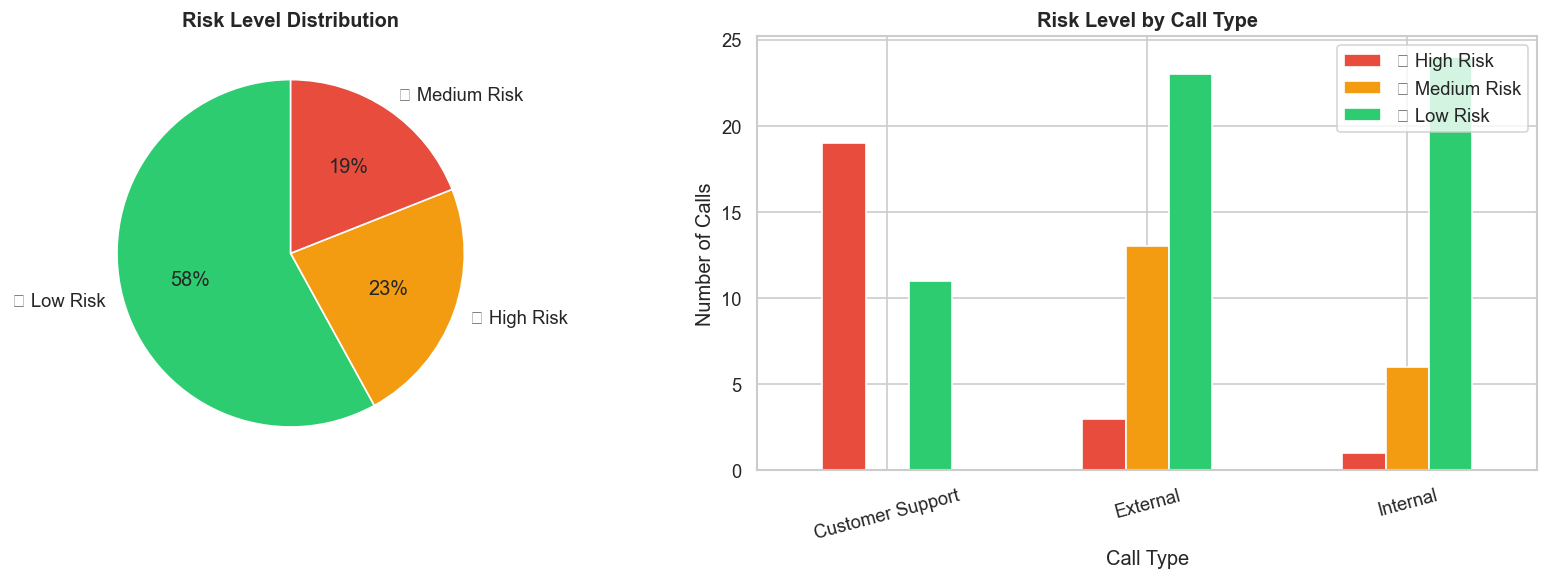


✅ Chart saved → high_risk_calls.png


In [8]:
print("=" * 55)
print("SECTION 4 — HIGH RISK CALL DETECTION")
print("=" * 55)

def calculate_risk_score(row):
    score = 0

    # Sentiment score (low = high risk)
    if row["sentiment_score"] < 2.0:   score += 4
    elif row["sentiment_score"] < 3.0: score += 2
    elif row["sentiment_score"] < 3.5: score += 1

    # Sentiment label
    if row["sentiment"] == "very-negative": score += 3
    elif row["sentiment"] == "negative":    score += 2
    elif row["sentiment"] == "mixed-negative": score += 1

    # Negative sentences dominate
    if row["negative_sents"] > row["positive_sents"]: score += 2

    # Call type (support = higher risk)
    if row["call_type"] == "Customer Support": score += 1

    # Many action items = unresolved issues
    if row["num_action_items"] >= 5: score += 1

    return score

def risk_label(score):
    if score >= 6:   return "🔴 High Risk"
    elif score >= 3: return "🟡 Medium Risk"
    else:            return "🟢 Low Risk"

# Apply risk scoring
df["risk_score"] = df.apply(calculate_risk_score, axis=1)
df["risk_level"] = df["risk_score"].apply(risk_label)

# Print risk distribution
print(f"\n⚠️  Risk Distribution:")
for level, count in df["risk_level"].value_counts().items():
    pct = count/len(df)*100
    print(f"   {level:<20} → {count} calls ({pct:.0f}%)")

# Show top 10 high risk calls
high_risk = df[df["risk_level"] == "🔴 High Risk"] \
              .sort_values("risk_score", ascending=False)

print(f"\n🔴 TOP HIGH RISK CALLS:")
print(f"{'─'*70}")
for _, row in high_risk.head(10).iterrows():
    print(f"\n  📞 {row['title']}")
    print(f"     Type       : {row['call_type']}")
    print(f"     Sentiment  : {row['sentiment']} ({row['sentiment_score']})")
    print(f"     Risk Score : {row['risk_score']}")
    print(f"     Summary    : {row['summary'][:120]}...")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_counts = df["risk_level"].value_counts()
colors_risk = ["#2ecc71", "#f39c12", "#e74c3c"]
axes[0].pie(risk_counts.values,
            labels=risk_counts.index,
            colors=colors_risk,
            autopct="%1.0f%%",
            startangle=90)
axes[0].set_title("Risk Level Distribution", fontweight="bold")

# Risk by call type
risk_type = pd.crosstab(df["call_type"], df["risk_level"])
risk_type.plot(kind="bar", ax=axes[1],
               color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[1].set_title("Risk Level by Call Type", fontweight="bold")
axes[1].set_xlabel("Call Type")
axes[1].set_ylabel("Number of Calls")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}high_risk_calls.png", bbox_inches="tight")
plt.show()
print("\n✅ Chart saved → high_risk_calls.png")

SECTION 5 — KEY MOMENTS ANALYSIS
✅ Total key moments : 402

📊 Moment Types:
   concern                   →  84  ████████████████████████████████████████████████████████████████████████████████████
   positive_pivot            →  76  ████████████████████████████████████████████████████████████████████████████
   churn_signal              →  61  █████████████████████████████████████████████████████████████
   technical_issue           →  54  ██████████████████████████████████████████████████████
   feature_gap               →  51  ███████████████████████████████████████████████████
   action_item               →  43  ███████████████████████████████████████████
   praise                    →  23  ███████████████████████
   pricing_offer             →  10  ██████████


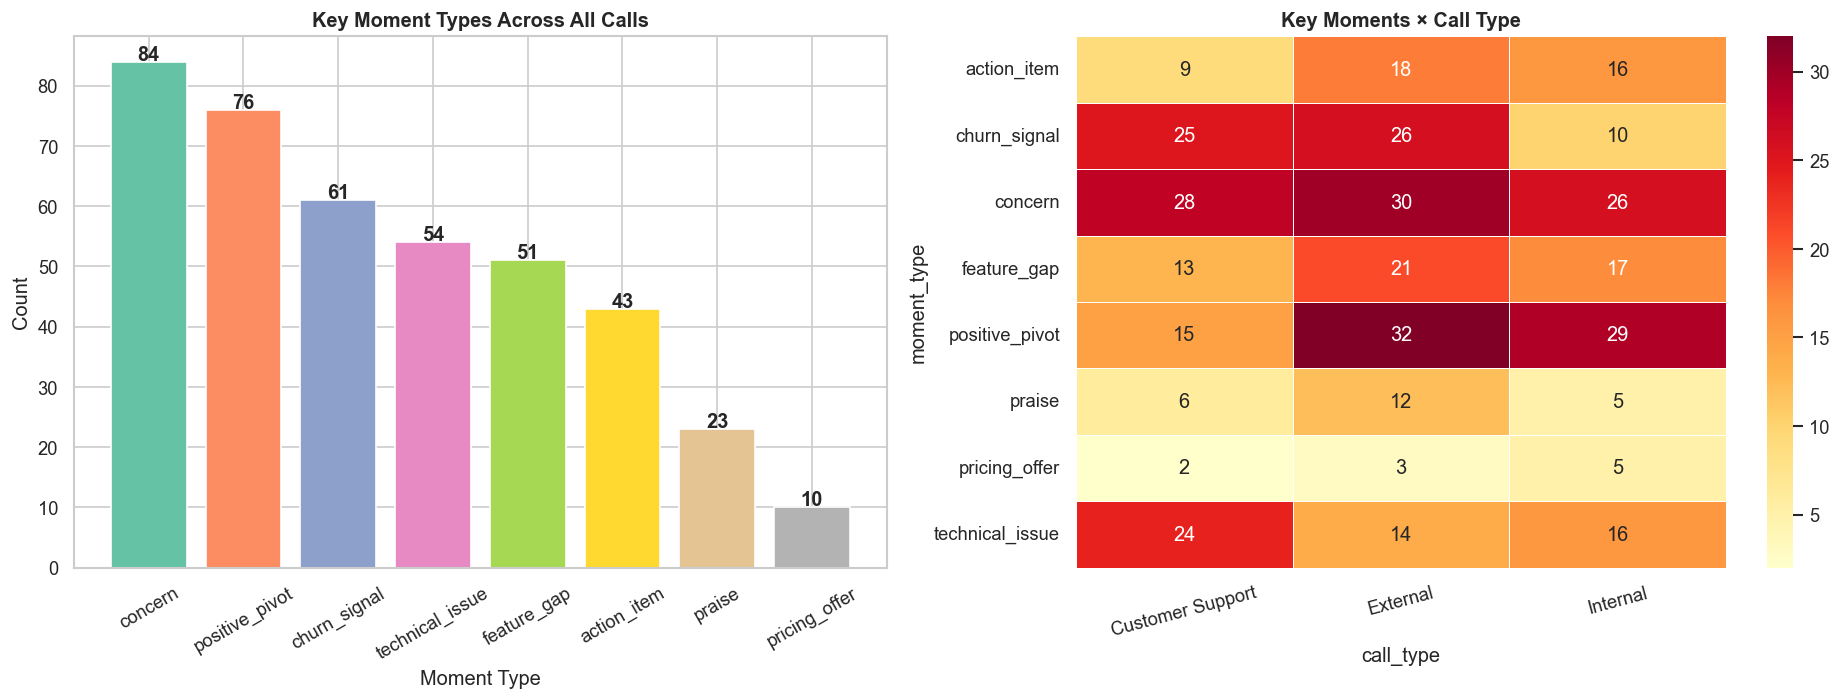


⚠️  TOP CONCERNS (84 total):

   📞 Competitive Landscape Review
      Jordan flags SentinelShield appearing more frequently in deal cycles, identified as the most immediate competitive threa

   📞 Detect Outage - Root Cause Analysis
      Sofia expresses frustration that a known single point of failure was never prioritized, resulting in six hours of zero c

   📞 Support Case #6977 - Brightpath Commerce Slow Back
      Kendra describes nightly backup jobs taking 4-6 hours, up from under 90 minutes, lasting three weeks with real operation

   📞 Aegis / Brightpath Commerce - Detect Module Deploy
      Kendra confirms spring peak season deadline in late March, creating urgency for the deployment timeline

   📞 Detect Outage - Escalation Bridge
      Diana confirms all Detect customers have zero event processing and zero alert visibility during the outage

✅ Chart saved → key_moments.png


In [9]:
print("=" * 55)
print("SECTION 5 — KEY MOMENTS ANALYSIS")
print("=" * 55)

# Flatten all key moments
all_moments = []
for _, row in df.iterrows():
    for moment in row["key_moments"]:
        all_moments.append({
            "call_title"  : row["title"],
            "call_type"   : row["call_type"],
            "theme"       : row["theme"],
            "sentiment"   : row["sentiment"],
            "moment_type" : moment.get("type", "unknown"),
            "moment_text" : moment.get("text", ""),
            "speaker"     : moment.get("speaker", ""),
            "time"        : moment.get("time", 0)
        })

moments_df = pd.DataFrame(all_moments)
print(f"✅ Total key moments : {len(moments_df)}")
print(f"\n📊 Moment Types:")
for mtype, count in moments_df["moment_type"].value_counts().items():
    bar = "█" * count
    print(f"   {mtype:<25} → {count:3d}  {bar}")

# Visualize moment types
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

moment_counts = moments_df["moment_type"].value_counts()
colors = sns.color_palette("Set2", len(moment_counts))
axes[0].bar(moment_counts.index, moment_counts.values, color=colors)
axes[0].set_title("Key Moment Types Across All Calls", fontweight="bold")
axes[0].set_xlabel("Moment Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(moment_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Moments by call type
moment_type_cross = pd.crosstab(moments_df["moment_type"],
                                 moments_df["call_type"])
sns.heatmap(moment_type_cross, annot=True, fmt="d",
            cmap="YlOrRd", ax=axes[1], linewidths=0.5)
axes[1].set_title("Key Moments × Call Type", fontweight="bold")
plt.setp(axes[1].get_xticklabels(), rotation=15)
plt.setp(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}key_moments.png", bbox_inches="tight")
plt.show()

# Show concern moments
concerns = moments_df[moments_df["moment_type"] == "concern"]
print(f"\n⚠️  TOP CONCERNS ({len(concerns)} total):")
for _, m in concerns.head(5).iterrows():
    print(f"\n   📞 {m['call_title'][:50]}")
    print(f"      {m['moment_text'][:120]}")
print("\n✅ Chart saved → key_moments.png")

In [10]:
print("=" * 65)
print("SECTION 6 — BUSINESS RECOMMENDATIONS")
print("=" * 65)

high_risk_count  = len(df[df["risk_level"] == "🔴 High Risk"])
med_risk_count   = len(df[df["risk_level"] == "🟡 Medium Risk"])
support_avg      = df[df["call_type"]=="Customer Support"]["sentiment_score"].mean()
top_neg_theme    = df.groupby("theme")["sentiment_score"].mean().idxmin()
top_neg_score    = df.groupby("theme")["sentiment_score"].mean().min()
compliance_pct   = len(df[df["theme"]=="Compliance and Security"]) / len(df) * 100

print(f"""
┌─────────────────────────────────────────────────────────────┐
│  FINDINGS SUMMARY                                           │
├─────────────────────────────────────────────────────────────┤
│  🔴 High Risk Calls     : {high_risk_count:2d} calls need urgent follow-up  │
│  🟡 Medium Risk Calls   : {med_risk_count:2d} calls need monitoring         │
│  📉 Support Sentiment   : {support_avg:.2f}/5.0 (below neutral 3.0)    │
│  🚨 Most Negative Theme : {top_neg_theme[:30]:<30}│
│  📌 Compliance Calls    : {compliance_pct:.0f}% of all calls              │
└─────────────────────────────────────────────────────────────┘

📋 RECOMMENDATIONS:

1. 🔴 URGENT — Follow up on {high_risk_count} high-risk calls immediately
   → Assign senior account managers to at-risk accounts
   → Target: resolve within 48 hours

2. 🛡️  COMPLIANCE — {compliance_pct:.0f}% of calls about compliance/security
   → Create dedicated compliance support team
   → Build self-service compliance documentation portal

3. 📉 SUPPORT QUALITY — Avg score {support_avg:.2f}/5.0
   → Support calls are shortest (19.3 mins) but most painful
   → Invest in better first-call resolution training
   → Target: raise support sentiment to 3.5+

4. ⚡ PRODUCT GAP — Feature requests appear in key moments
   → Route feature_gap moments directly to product team
   → Build feedback loop between support and product

5. 📊 MONITORING — Set up weekly sentiment dashboard
   → Alert when any theme drops below 2.5
   → Track high-risk accounts monthly
""")

# Save high risk calls for action
high_risk_export = df[df["risk_level"] == "🔴 High Risk"][[
    "title", "call_type", "theme", "sentiment",
    "sentiment_score", "risk_score", "summary"
]]
high_risk_export.to_csv(f"{EXPORTS_PATH}high_risk_calls.csv", index=False)
df.to_csv(DATA_PATH, index=False)

print(f"✅ High risk calls → data/exports/high_risk_calls.csv")
print(f"✅ Full DataFrame  → data/processed/all_calls.csv")
print(f"\n🚀 Ready for 05_bonus_insights.ipynb!")

SECTION 6 — BUSINESS RECOMMENDATIONS

┌─────────────────────────────────────────────────────────────┐
│  FINDINGS SUMMARY                                           │
├─────────────────────────────────────────────────────────────┤
│  🔴 High Risk Calls     : 23 calls need urgent follow-up  │
│  🟡 Medium Risk Calls   : 19 calls need monitoring         │
│  📉 Support Sentiment   : 2.87/5.0 (below neutral 3.0)    │
│  🚨 Most Negative Theme : Incident and Problem Managemen│
│  📌 Compliance Calls    : 39% of all calls              │
└─────────────────────────────────────────────────────────────┘

📋 RECOMMENDATIONS:

1. 🔴 URGENT — Follow up on 23 high-risk calls immediately
   → Assign senior account managers to at-risk accounts
   → Target: resolve within 48 hours

2. 🛡️  COMPLIANCE — 39% of calls about compliance/security
   → Create dedicated compliance support team
   → Build self-service compliance documentation portal

3. 📉 SUPPORT QUALITY — Avg score 2.87/5.0
   → Support calls are shor